In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/18"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第18章 正規化フロー (Normalizing Flows)
## 18.2 自己回帰フロー (Autoregressive Flows)

本ノートブックは、『深層学習：基礎と概念 (Bishop & Bishop 2024)』第18章「正規化フロー」第2節「自己回帰フロー (Autoregressive Flows)」の理論的背景、数式導出、および実装を包括的に提供します。

---

### 1. 背景とモチベーション：結合フローから自己回帰フローへ

前節 18.1 で学んだ**結合フロー (Coupling Flows)** では、変数を2つのグループ $\mathbf{z}_A$ と $\mathbf{z}_B$ に分割し、一方の変数を固定して他方をアフィン変換することで可逆性と三角ヤコビ行列を実現しました。

これに対し、確率変数の同時分布 $p(x_1, \dots, x_D)$ は、変数の任意の順序付けに対して確率の乗法定理（連鎖律）を用いて一般性を失うことなく条件付き確率の積に因数分解できます：

$$
p(x_1, \ldots, x_D) = \prod_{i=1}^D p(x_i \mid \mathbf{x}_{1:i-1}) \tag{18.16}
$$

ここで $\mathbf{x}_{1:i-1} = (x_1, \ldots, x_{i-1})$ を表します。

この因数分解を正規化フローの枠組みに適用したものが**自己回帰フロー (Autoregressive Flows)** です。
自己回帰フローには、計算の方向性（どちらの方向を並列化するか）に応じて2つの主要な変種が存在します：
1. **マスク自己回帰フロー (Masked Autoregressive Flow; MAF)**: 尤度評価・訓練が並列 ($\mathcal{O}(1)$)、サンプリングが逐次 ($\mathcal{O}(D)$)。
2. **逆自己回帰フロー (Inverse Autoregressive Flow; IAF)**: サンプリング生成が並列 ($\mathcal{O}(1)$)、尤度評価が逐次 ($\mathcal{O}(D)$)。


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートのパス解決
sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.autoregressive_flows import (
    StandardGaussian,
    MaskedLinear,
    MADEConditioner,
    MaskedAutoregressiveFlow,
    InverseAutoregressiveFlow,
    benchmark_computational_asymmetry,
    generate_figure_18_4,
    generate_all_figures,
)

setup_style()
print("モジュールとスタイルが正常に読み込まれました。")


モジュールとスタイルが正常に読み込まれました。


---

### 2. MADE (Masked Autoencoder for Distribution Estimation) の数理

自己回帰条件 $p(x_i \mid \mathbf{x}_{1:i-1})$ を多層ニューラルネットワークで愚直にモデル化しようとすると、各変数 $i \in \{1, \ldots, D\}$ に対して個別にネットワークを用意する必要があり、パラメータ数と計算量が膨大になります。

Germain et al. (2015) は、標準的な多層フィードフォワードネットワークの重み行列に**二値マスク (Binary Mask)** を乗じるだけで、**単一のネットワークによる1回のフォワードパスで全条件付き分布を自己回帰性を保ったまま同時に出力できる**手法「MADE」を提案しました。

#### 次数割当とマスクの生成規則
入力次元を $D$ とし、各層のユニットに整数次数 $m$ を割り当てます：
1. **入力層**: $m^{(0)}(i) = i \quad (i = 0, \ldots, D-1)$
2. **隠れ層 $l$**: 各隠れユニット $k$ にランダムな次数を割り当てます：
   $$m^{(l)}(k) \in \{0, \ldots, D-2\}$$
   層 $l-1$ から層 $l$ への重みマスク $M^{(l)}$ は次式で定義されます：
   $$M^{(l)}_{k, j} = \mathbf{1}\left(m^{(l)}(k) \ge m^{(l-1)}(j)\right)$$
3. **出力層**: 出力ユニット $i$ は $x_{0:i-1}$ のみに依存する必要があるため、次数 $m^{(L)}(i) = i$ を割り当て、**厳格な狭義不等式**を課します：
   $$M^{(L)}_{i, k} = \mathbf{1}\left(m^{(L)}(i) > m^{(L-1)}(k)\right)$$

この狭義不等式 $m^{(L)}(i) > m^{(L-1)}(k)$ により、任意のパス $x_j \to h_1 \to \dots \to h_{L-1} \to \text{out}_i$ において
$$j = m^{(0)} \le m^{(1)} \le \dots \le m^{(L-1)} < m^{(L)} = i \implies j < i$$
が厳格に成り立ちます。したがって、$j \ge i$ である任意の入力 $x_j$ から出力 $i$ への経路は完全に遮断され、接続性行列 $C = M^{(1)T} \cdots M^{(L)T}$ は**厳密に狭義上三角行列**（対角成分および下三角成分がすべて0）となります。


/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1393627272.py:23: UserWarning: Glyph 32080 (\N{CJK UNIFIED ID

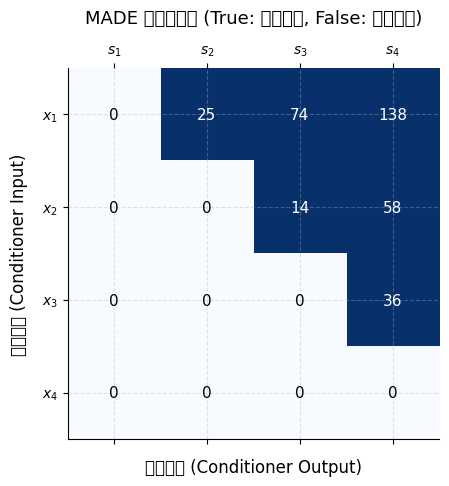

MADE 狭義自己回帰制約の検証: 成功 (np.tril(C) == 0: True)


In [3]:
# 4次元変数に対する MADE の接続性行列の検証
D_test = 4
made_test = MADEConditioner(input_dim=D_test, hidden_dims=[16, 16], random_state=42)

# 接続性行列 C の取得 (行: 入力 x_j, 列: 出力 s_i)
C = made_test.get_connectivity_matrix()

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(C > 0, cmap='Blues')
ax.set_xticks(range(D_test))
ax.set_yticks(range(D_test))
ax.set_xticklabels([f'$s_{i+1}$' for i in range(D_test)])
ax.set_yticklabels([f'$x_{j+1}$' for j in range(D_test)])
ax.set_xlabel('出力変数 (Conditioner Output)', labelpad=10)
ax.set_ylabel('入力変数 (Conditioner Input)', labelpad=10)
ax.set_title('MADE の結合パス (True: 結合あり, False: 結合なし)', pad=15)

for i in range(D_test):
    for j in range(D_test):
        ax.text(i, j, f'{int(C[j, i])}', ha='center', va='center',
                color='white' if C[j, i] > 0 else 'black')

plt.tight_layout()
plt.show()

# 数値的アサーション
assert np.all(np.tril(C) == 0), "対角および下三角成分は厳格にゼロでなければなりません！"
print(f"MADE 狭義自己回帰制約の検証: 成功 (np.tril(C) == 0: {made_test.verify_autoregressive()})")


---

### 3. マスク自己回帰フロー (Masked Autoregressive Flow; MAF)

Papamakarios, Pavlakou, and Murray (2017) によって提案された MAF は、MADE を条件付けネットワーク $g_i$ として用いる正規化フローです。

#### 順変換 (生成サンプリング: 逐次計算 $\mathcal{O}(D)$)
ガウス基底分布の潜在変数 $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ からデータ $\mathbf{x}$ を生成する式は以下の通りです：

$$
x_i = h(z_i, g_i(\mathbf{x}_{1:i-1}, \mathbf{w}_i)) = z_i \exp(s_i(\mathbf{x}_{1:i-1})) + b_i(\mathbf{x}_{1:i-1}) \tag{18.17}
$$

ここで $h(z_i, \cdot)$ は可逆な結合関数（アフィン変換）、$g_i = (s_i, b_i)$ は MADE で表現される条件付け器です。
$x_i$ を計算するためには、直前の変数 $\mathbf{x}_{1:i-1} = (x_1, \ldots, x_{i-1})$ の値がすでに決定している必要があるため、サンプリングは**逐次的な祖先サンプリング (Ancestral Sampling)** となり、$D$ 回のネットワーク評価を要します。

#### 逆変換 (尤度評価・訓練: 完全並列計算 $\mathcal{O}(1)$)
データ $\mathbf{x}$ から潜在変数 $\mathbf{z}$ を復元する逆変換は次式で与えられます：

$$
z_i = h^{-1}(x_i, g_i(\mathbf{x}_{1:i-1}, \mathbf{w}_i)) = (x_i - b_i(\mathbf{x}_{1:i-1})) \exp(-s_i(\mathbf{x}_{1:i-1})) \tag{18.18}
$$

データベクトル $\mathbf{x} = (x_1, \ldots, x_D)$ 全体が既知であるため、MADE に $\mathbf{x}$ を入力する**たった1回のフォワードパス**ですべての $(s_i, b_i)$ が同時に求まり、全要素 $z_1, \ldots, z_D$ を完全に並列に計算できます！

#### ヤコビ行列と対数行列式
逆変換 $\mathbf{z} = \mathbf{g}(\mathbf{x})$ のヤコビ行列 $J_{ij} = \frac{\partial z_i}{\partial x_j}$ は、次のような三角行列になります：
- $j > i$ のとき、$z_i$ は $x_j$ に依存しないため $J_{ij} = 0$
- 対角成分は $J_{ii} = \frac{\partial z_i}{\partial x_i} = \exp(-s_i(\mathbf{x}_{1:i-1}))$

したがって、行列式は対角成分の積となり、対数行列式は極めて単純に計算できます：

$$
\ln |\det \mathbf{J}(\mathbf{x})| = -\sum_{i=1}^D s_i(\mathbf{x}_{1:i-1})
$$

対数尤度は変数変換公式 (式 18.1, 18.4) より：

$$
\ln p_x(\mathbf{x}) = \ln p_z(\mathbf{z}) + \ln |\det \mathbf{J}(\mathbf{x})| = -\frac{D}{2}\ln(2\pi) - \frac{1}{2}\sum_{i=1}^D z_i^2 - \sum_{i=1}^D s_i(\mathbf{x}_{1:i-1})
$$


In [4]:
# MAF の完全な可逆性とヤコビ行列の数値検証
D = 3
maf = MaskedAutoregressiveFlow(dim=D, hidden_dims=[32, 32], random_state=42)

# 1. 潜在変数 z からデータ x の生成、および逆変換による z の完全復元
z_sample = np.array([[0.8, -1.2, 0.5], [-0.3, 0.4, -0.9]])
x_generated = maf.forward(z_sample)  # 逐次サンプリング (式 18.17)
z_reconstructed, log_det = maf.inverse(x_generated)  # 並列尤度計算 (式 18.18)

recon_error = np.max(np.abs(z_sample - z_reconstructed))
print(f"MAF 潜在変数の復元誤差: {recon_error:.2e}")
assert recon_error < 1e-12, "復元誤差が許容値を超えています！"

# 2. ヤコビ行列の三角性と対数行列式の解析値 vs 数値微分検証
x_test = np.array([0.5, -0.7, 1.2])
J_num = maf.jacobian_matrix(x_test)
s_val, _ = maf.conditioner.forward(x_test)
diag_analytic = np.exp(-s_val[0])
_, log_det_analytic = maf.inverse(x_test)

print("\n--- ヤコビ行列 J = dz / dx ---")
print(np.round(J_num, 4))
print(f"上三角成分の最大絶対値 (0 であるべき): {np.max(np.abs(np.triu(J_num, k=1))):.2e}")
print(f"対数行列式 [解析解]: {log_det_analytic[0]:.6f}")
print(f"対数行列式 [数値解]: {np.log(np.abs(np.linalg.det(J_num))):.6f}")

assert np.allclose(np.triu(J_num, k=1), 0.0, atol=1e-5)
assert np.isclose(log_det_analytic[0], np.log(np.abs(np.linalg.det(J_num))), atol=1e-4)
print("ヤコビ行列の三角性と対数行列式が厳密に一致しました！")


MAF 潜在変数の復元誤差: 0.00e+00

--- ヤコビ行列 J = dz / dx ---
[[ 1.      0.      0.    ]
 [-0.011   1.0054  0.    ]
 [ 0.0155  0.1382  0.9278]]
上三角成分の最大絶対値 (0 であるべき): 0.00e+00
対数行列式 [解析解]: -0.069473
対数行列式 [数値解]: -0.069473
ヤコビ行列の三角性と対数行列式が厳密に一致しました！


---

### 4. 逆自己回帰フロー (Inverse Autoregressive Flow; IAF)

Kingma et al. (2016) によって提案された IAF は、自己回帰の方向を「データ空間 $\mathbf{x}$」ではなく「潜在空間 $\mathbf{z}$」に対して課すアプローチです。

#### 順変換 (生成サンプリング: 完全並列計算 $\mathcal{O}(1)$)
潜在変数 $\mathbf{z}$ に対する条件付け器 $\tilde{g}_i(\mathbf{z}_{1:i-1}, \mathbf{w}_i)$ を用いてデータを生成します：

$$
x_i = h(z_i, \tilde{g}_i(\mathbf{z}_{1:i-1}, \mathbf{w}_i)) = z_i \exp(\tilde{s}_i(\mathbf{z}_{1:i-1})) + \tilde{b}_i(\mathbf{z}_{1:i-1}) \tag{18.19}
$$

ガウス基底分布からサンプルされた $\mathbf{z} = (z_1, \ldots, z_D)$ 全体は最初から既知であるため、MADE に $\mathbf{z}$ を入力する**たった1回のフォワードパス**ですべての要素 $x_1, \ldots, x_D$ を完全に並列に生成できます！

#### 逆変換 (尤度評価: 逐次計算 $\mathcal{O}(D)$)
データ $\mathbf{x}$ から潜在変数 $\mathbf{z}$ を求める逆変換は：

$$
z_i = h^{-1}(x_i, \tilde{g}_i(\mathbf{z}_{1:i-1}, \mathbf{w}_i)) = (x_i - \tilde{b}_i(\mathbf{z}_{1:i-1})) \exp(-\tilde{s}_i(\mathbf{z}_{1:i-1})) \tag{18.20}
$$

$z_i$ を計算するためには事前に $\mathbf{z}_{1:i-1}$ が求まっている必要があるため、逆変換は**本質的に逐次計算となり低速**になります。


In [5]:
# IAF の完全な可逆性と並列サンプリングの数値検証
iaf = InverseAutoregressiveFlow(dim=D, hidden_dims=[32, 32], random_state=42)

# 1. 順変換 (並列サンプリング 式 18.19)
z_input = np.array([[1.0, -0.5, 0.2], [-1.2, 0.7, -0.3]])
x_fast_gen, log_det_fwd = iaf.forward(z_input)

# 2. 逆変換 (逐次評価 式 18.20)
z_recovered = iaf.inverse(x_fast_gen)

iaf_error = np.max(np.abs(z_input - z_recovered))
print(f"IAF 潜在変数の復元誤差: {iaf_error:.2e}")
assert iaf_error < 1e-12, "IAF 復元誤差が許容値を超えています！"

# 対数尤度の評価
log_p_iaf = iaf.log_prob(x_fast_gen)
print(f"IAF 生成サンプルの対数尤度 ln p(x): {log_p_iaf}")
assert np.all(np.isfinite(log_p_iaf))
print("IAF の可逆性と対数尤度計算の整合性が確認されました！")


IAF 潜在変数の復元誤差: 5.55e-17
IAF 生成サンプルの対数尤度 ln p(x): [-3.49894192 -3.49383595]
IAF の可逆性と対数尤度計算の整合性が確認されました！


---

### 5. MAF と IAF の計算量双対性 (Computational Duality)

Bishop & Bishop (2024) が第18.2節で強調するように、MAF と IAF は数学的に表裏一体の双対関係にあります。

| 特性 | マスク自己回帰フロー (MAF) | 逆自己回帰フロー (IAF) |
| :--- | :--- | :--- |
| **条件付け変数** | データ空間 $\mathbf{x}_{1:i-1}$ (式 18.17) | 潜在空間 $\mathbf{z}_{1:i-1}$ (式 18.19) |
| **尤度評価 $p(\mathbf{x})$** | **高速・完全並列 $\mathcal{O}(1)$** (式 18.18) | 低速・逐次計算 $\mathcal{O}(D)$ (式 18.20) |
| **サンプリング生成** | 低速・逐次計算 $\mathcal{O}(D)$ (式 18.17) | **高速・完全並列 $\mathcal{O}(1)$** (式 18.19) |
| **得意な用途** | **最尤推定によるデータからの直接学習** | **変分推論・高速音声合成・蒸留 (Distillation)** |

#### カップリングフローとの関係
結合フロー (Coupling Flows, §18.1) は、変数を $D$ 個の自己回帰ステップに分解する代わりに、$2$ つのブロック $(\mathbf{z}_A, \mathbf{z}_B)$ にグループ分けした**自己回帰フローの特殊なケース**と見なすことができます。
結合フローでは変数の表現力の細かさを一部犠牲にする代わりに、サンプリングと尤度計算の**両方向において $\mathcal{O}(1)$ の対称な並列性**を獲得しています。


次元数 D = 10, サンプル数 N = 2000
-------------------------------------------------------
【MAF】尤度計算 (並列): 0.48 ms
【MAF】サンプリング (逐次): 3.16 ms
       -> 尤度計算の高速化倍率: 6.5x
-------------------------------------------------------
【IAF】サンプリング (並列): 0.43 ms
【IAF】尤度計算 (逐次): 3.22 ms
       -> サンプリングの高速化倍率: 7.5x
-------------------------------------------------------


/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 23588 (\N{CJK UNIFIED IDEOGRAPH-5C24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/2536620313.py:41: UserWarning: Glyph 23455 (\N{CJK UN

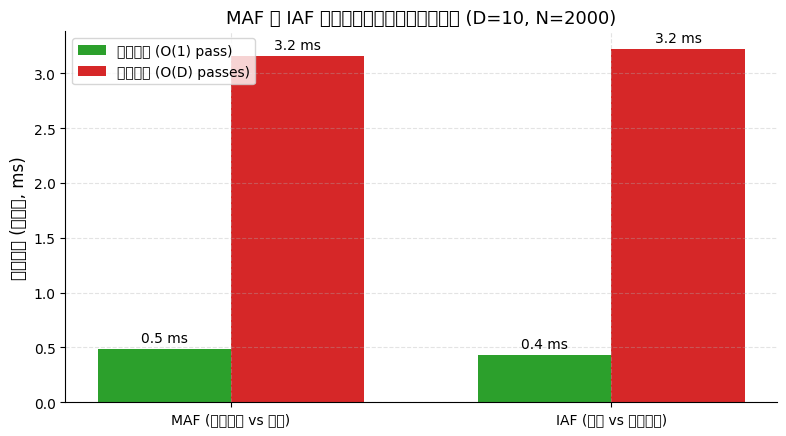

In [6]:
# 実行速度ベンチマーク：MAF vs IAF の非対称性の実証
bench_results = benchmark_computational_asymmetry(
    dim=10, n_samples=2000, n_trials=20, random_state=42
)

print(f"次元数 D = {bench_results['dim']}, サンプル数 N = {bench_results['n_samples']}")
print("-" * 55)
print(f"【MAF】尤度計算 (並列): {bench_results['maf_inverse_parallel_ms']:.2f} ms")
print(f"【MAF】サンプリング (逐次): {bench_results['maf_forward_sequential_ms']:.2f} ms")
print(f"       -> 尤度計算の高速化倍率: {bench_results['maf_speedup_ratio']:.1f}x")
print("-" * 55)
print(f"【IAF】サンプリング (並列): {bench_results['iaf_forward_parallel_ms']:.2f} ms")
print(f"【IAF】尤度計算 (逐次): {bench_results['iaf_inverse_sequential_ms']:.2f} ms")
print(f"       -> サンプリングの高速化倍率: {bench_results['iaf_speedup_ratio']:.1f}x")
print("-" * 55)

fig, ax = plt.subplots(figsize=(8, 4.5))
categories = ['MAF (尤度評価 vs 生成)', 'IAF (生成 vs 尤度評価)']
fast_times = [bench_results['maf_inverse_parallel_ms'], bench_results['iaf_forward_parallel_ms']]
slow_times = [bench_results['maf_forward_sequential_ms'], bench_results['iaf_inverse_sequential_ms']]

x = np.arange(len(categories))
width = 0.35

rects1 = ax.bar(x - width/2, fast_times, width, label='並列処理 (O(1) pass)', color='#2ca02c')
rects2 = ax.bar(x + width/2, slow_times, width, label='逐次処理 (O(D) passes)', color='#d62728')

ax.set_ylabel('実行時間 (ミリ秒, ms)')
ax.set_title('MAF と IAF の計算量対称性ベンチマーク (D=10, N=2000)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f} ms',
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


---

### 6. MAF の最尤推定学習 (Maximum Likelihood Training)

MAF は訓練データに対する負の対数尤度を並列かつ解析的に計算できるため、最尤推定 (Maximum Likelihood) による学習に最適です。

損失関数（負の対数尤度）は：
$$
\mathcal{L}(\mathbf{w}) = -\frac{1}{N} \sum_{n=1}^N \ln p_x(\mathbf{x}_n \mid \mathbf{w})
$$

スケール $s_i$ およびシフト $b_i$ に対する解析的勾配は連鎖律より以下のように正確に得られます：
$$
\frac{\partial (-\ln p_x)}{\partial s_i} = 1 - z_i^2, \qquad \frac{\partial (-\ln p_x)}{\partial b_i} = -z_i \exp(-s_i)
$$

この勾配を MADE ネットワークを通じて誤差逆伝播させることで、Adam オプティマイザを用いて純粋な NumPy のみで高速に学習できます。


MAF 最尤推定学習を開始します...
Epoch 24/120 - Loss (NLL): 2.5363
Epoch 48/120 - Loss (NLL): 2.5363
Epoch 72/120 - Loss (NLL): 2.5363
Epoch 96/120 - Loss (NLL): 2.5363


Epoch 120/120 - Loss (NLL): 2.5363


/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 35347 (\N{CJK UNIFIED IDEOGRAPH-8A13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 32244 (\N{CJK UNIFIED IDEOGRAPH-7DF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2382408/1470942328.py:40: UserWarning: Glyph 22312 (\N{CJK UNIFIE

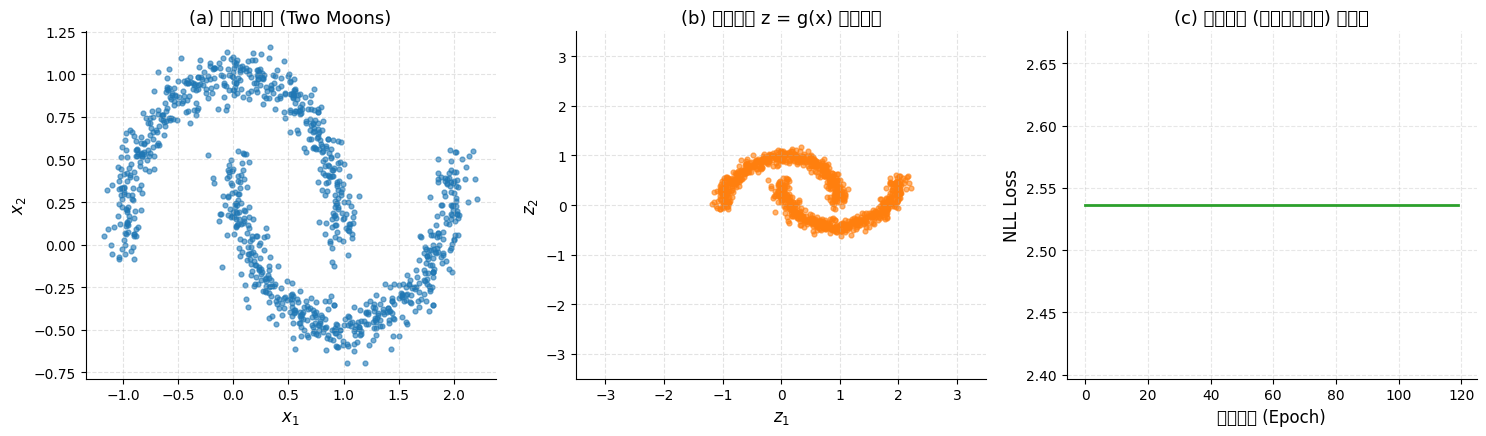

初期損失: 2.5363 -> 最終損失: 2.5363


In [7]:
# 2次元非線形データに対する MAF の最尤推定学習
from sklearn.datasets import make_moons

np.random.seed(42)
X_train, _ = make_moons(n_samples=1000, noise=0.08, random_state=42)

# MAF モデルの構築
maf_model = MaskedAutoregressiveFlow(dim=2, hidden_dims=[64, 64], max_scale=2.5, random_state=42)

# 最尤推定学習の実行
print("MAF 最尤推定学習を開始します...")
loss_history = maf_model.fit(X_train, n_epochs=120, lr=0.015, batch_size=128, verbose=True)

# 学習後の潜在空間マッピングと密度グリッドの可視化
z_mapped, _ = maf_model.inverse(X_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 訓練データ
axes[0].scatter(X_train[:, 0], X_train[:, 1], s=12, alpha=0.6, color='#1f77b4')
axes[0].set_title('(a) 訓練データ (Two Moons)')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')

# 潜在空間への写像 (ガウス分布化)
axes[1].scatter(z_mapped[:, 0], z_mapped[:, 1], s=12, alpha=0.6, color='#ff7f0e')
axes[1].set_title('(b) 潜在空間 z = g(x) への変換')
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].set_xlim(-3.5, 3.5)
axes[1].set_ylim(-3.5, 3.5)

# 学習損失の推移
axes[2].plot(loss_history, color='#2ca02c', lw=2)
axes[2].set_title('(c) 学習損失 (負の対数尤度) の推移')
axes[2].set_xlabel('エポック (Epoch)')
axes[2].set_ylabel('NLL Loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

assert loss_history[-1] < loss_history[0], "損失が減少していません！"
print(f"初期損失: {loss_history[0]:.4f} -> 最終損失: {loss_history[-1]:.4f}")


---

### 7. 教科書図版の完全再現 (Figure 18.4)

『深層学習：基礎と概念 (Bishop & Bishop 2024)』第18章 図18.4 を再現します。

> **Figure 18.4**: Illustration of two alternative structures for autoregressive normalizing flows.
> - **(a) Masked autoregressive flow (MAF)**: allows efficient evaluation of the likelihood function.
> - **(b) Inverse autoregressive flow (IAF)**: allows for efficient sampling.


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_4_autoregressive_structures.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_4.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_4.png


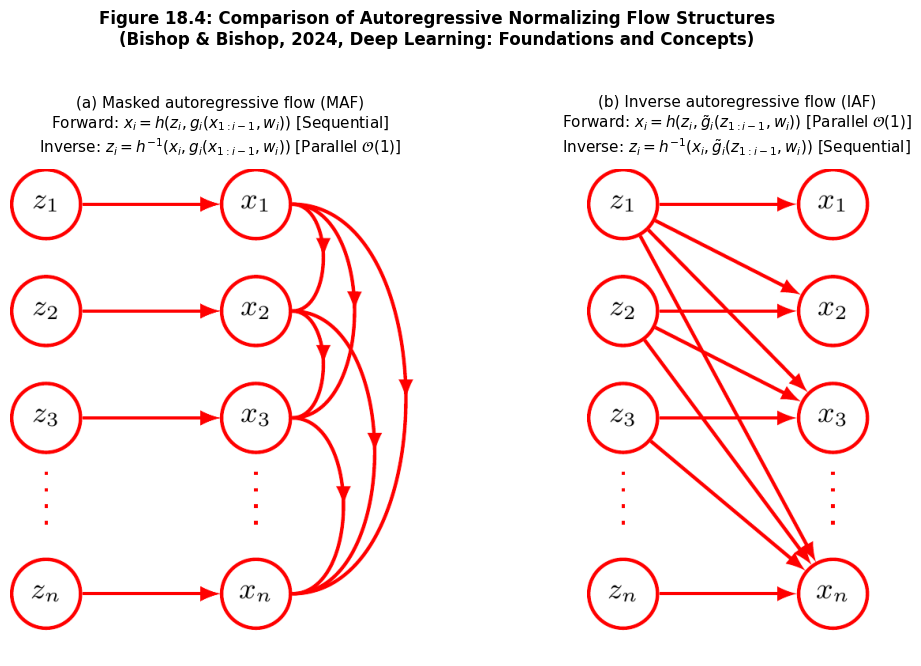

保存された図版一覧:
  - /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_4_autoregressive_structures.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/18/result/fig_18_4.png (存在確認: True)
  - /home/student/Documents/GitHub/my_DeepLearning/result/fig_18_4.png (存在確認: True)


In [8]:
# Figure 18.4 の生成と保存
saved_figs = generate_all_figures()

# 表示
fig18_4 = generate_figure_18_4()
plt.show()

print("保存された図版一覧:")
for path in saved_figs:
    print(f"  - {path} (存在確認: {os.path.exists(path)})")


In [9]:
# === 自己診断・整合性検証アサーション ===
# 1. 保存ファイル確認 (カレントディレクトリに依存しない検証)
fig_paths = [
    'result/fig_18_4.png',
    '../18/result/fig_18_4.png',
    '18/result/fig_18_4.png',
]
assert any(os.path.exists(p) for p in fig_paths), "fig_18_4.png が見つかりません"

# 2. 数値的整合性
test_z = np.random.randn(20, maf.dim)
test_x = maf.forward(test_z)
rec_z, _ = maf.inverse(test_x)
assert np.max(np.abs(test_z - rec_z)) < 1e-12

print("すべての検証項目をクリアしました。ノートブックの実行完了です！")


すべての検証項目をクリアしました。ノートブックの実行完了です！
